## Figure: RegMean Loss

/tmp/ipykernel_3442796/4058302514.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfp = dfp[df["model"] == "Olmo-3-7b"]


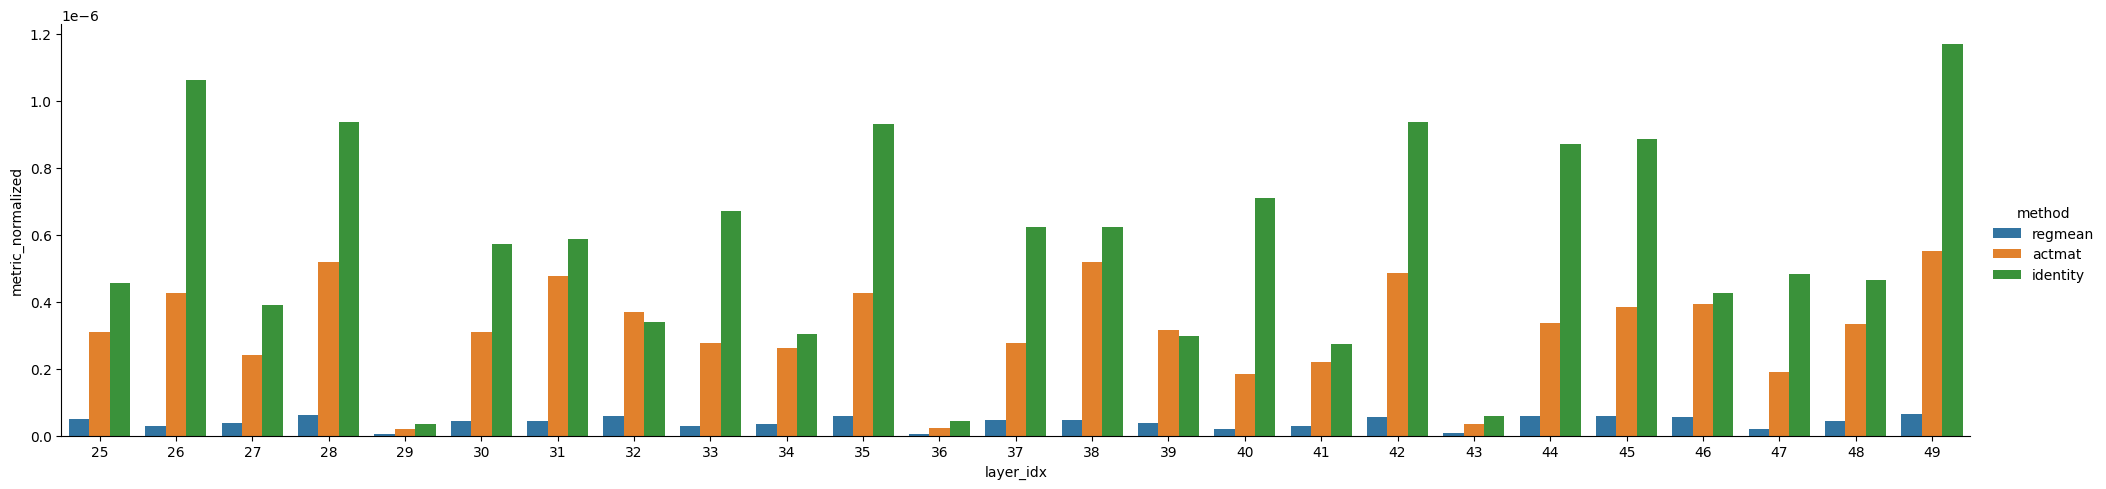

In [36]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
dfp = df[df["metric_type"] == "rm_loss"]
dfp = dfp[df["model"] == "Olmo-3-7b"]
# dfp = dfp[df["model"] == "t5-large"]
dfp["metric_normalized"] = dfp["metric"] / (dfp["Do"] * dfp["Di"])
dfp = dfp[dfp["method"].isin(["actmat", "regmean", "identity"])]
dfp = dfp[(dfp["layer_idx"] >= 25) & (dfp["layer_idx"] < 50)]

g = sns.catplot(
    dfp,
    x="layer_idx",
    y="metric_normalized",
    hue="method",
    hue_order=["regmean", "actmat", "identity"],
    # style="method",
    kind="bar",
    # markers=True,
    aspect=4,
)
# g.set(yscale="log")
# dfp = dfp.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat", "regmean"])
# dfp.style.format("{:.2e}")

In [1]:
# import pandas as pd
# import seaborn as sns

# df = pd.read_csv("../artifacts/analysis/cov-estimate-error/cov-estimate-error.csv")
# dfp = df.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat"])
# dfp.style.format("{:.2e}")

# import pandas as pd
# import seaborn as sns

# df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
# dfp = df[df["metric_type"] == "rm_loss"]
# dfp = dfp.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat", "regmean"])
# dfp.style.format("{:.2e}")

## Figure: Error terms

### Figure: layer-wise error terms

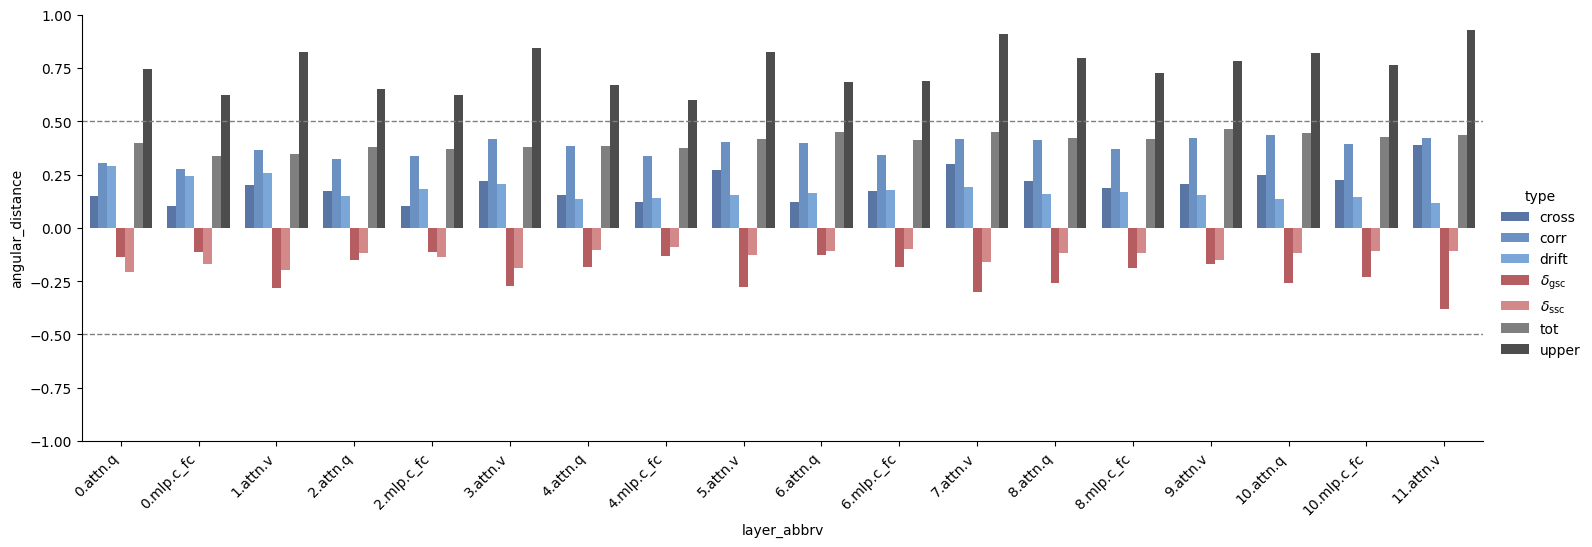

In [18]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results/{model}/group-fft-8"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))

# Filters:
# df = df[df["dataset"] == "Cars"]
# df = df[df["dataset"] == "DTD"]
df = df[df["dataset"] == "MNIST"]
# df = df[df["dataset"] == "SVHN"]
df = df[df["layer_idx"] % 4 == 0]

# Make layer abbrv
replace_strs = {
    "model.visual.transformer.resblocks.": "",
    ".weight": "",
}

df["layer_abbrv"] = df["layer_name"]
for old, new in replace_strs.items():
    df["layer_abbrv"] = df["layer_abbrv"].str.replace(old, new, regex=False)

hue_order = [
    "cross",
    "corr",
    "drift",
    r"$\delta_\text{gsc}$",
    r"$\delta_\text{ssc}$",
    "tot",
    "upper",
]

palette = {
    "cross": "#4C72B0",  # blues for the ε error terms
    "corr": "#5B8FCF",
    "drift": "#6BA6E8",
    r"$\delta_\text{gsc}$": "#C44E52",  # reds for the δ slack terms
    r"$\delta_\text{ssc}$": "#E07B7E",
    "tot": "#7F7F7F",  # grey for the total
    "upper": "#4D4D4D",  # darker grey for the triangle-inequality bound
}

g = sns.catplot(
    data=df,
    x="layer_abbrv",
    y="angular_distance",
    kind="bar",
    hue="type",
    aspect=3,
    hue_order=hue_order,
    palette=palette,
)
g.set_xticklabels(rotation=45, ha="right")
g.set(ylim=(-1.0, 1.0))
g.ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
g.ax.axhline(-0.5, color="grey", linestyle="--", linewidth=1)

### Figure: dataset-wise error terms

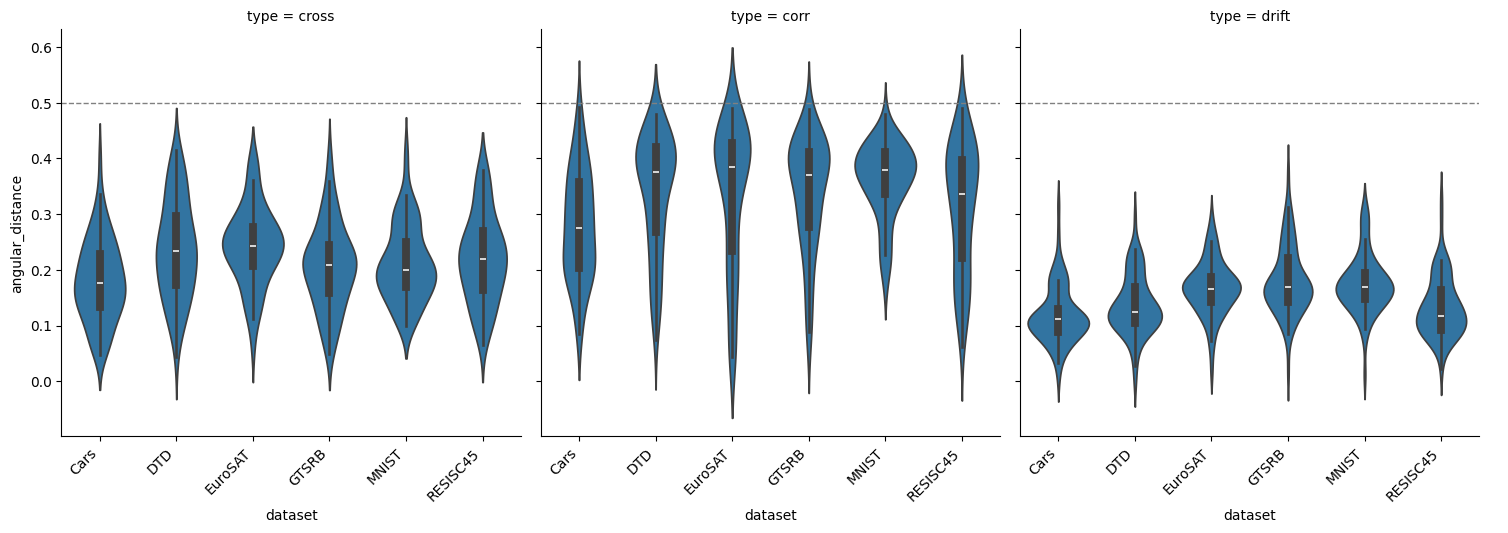

In [21]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results/{model}/group-fft-8"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))
df = df[df["type"].isin(["cross", "corr", "drift"])]

g = sns.catplot(data=df, x="dataset", y="angular_distance", kind="violin", col="type")
g.set_xticklabels(rotation=45, ha="right")
for ax in g.axes.flat:
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)

## Table: Error Terms

In [23]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results/{model}/group-fft-8"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))

dfp = df.pivot_table(index="type", columns="dataset", values="angular_distance")
dfp

dataset,Cars,DTD,EuroSAT,GTSRB,MNIST,RESISC45
type,,,,,,
$\delta_\text{gsc}$,-0.179592,-0.307068,-0.303579,-0.227361,-0.219166,-0.263689
$\delta_\text{ssc}$,-0.086386,-0.114179,-0.134116,-0.135077,-0.129760,-0.106676
corr,0.278984,0.337374,0.333555,0.336815,0.360813,0.312180
cross,0.180975,0.237507,0.242447,0.206055,0.211024,0.220130
drift,0.119398,0.136773,0.167534,0.180341,0.174745,0.133614
tot,0.313380,0.290408,0.305841,0.360772,0.397655,0.295558
upper,0.579358,0.711655,0.743537,0.723210,0.746582,0.665924


## Table: Merge Performance (ViT)

In [8]:
import os
import os.path as osp
import json
import numpy as np
import pandas as pd
import seaborn as sns

# methods = ["regmean", "actmat"]
method_to_method = {
    "pretrained": "Pretrained",
    "experts": "Experts",
    "regmean": "RegMean",
    "mean": "Average",
    "isoc": "Iso-C",
    "tsv": "TSV",
    "wudi": "WUDI",
    "actmat": "ACTMat",
}
method_to_special_subdir = {
    "pretrained": "pretrained",
    "multitask": "multitask",
    "experts": "experts",
}


configs = [
    # {"model": "t5-base", "group": "main"},
    {"model": "ViT-B-16", "group": "fft-8"},
]
rows = []
for cfg in configs:
    model, group = cfg["model"], cfg["group"]
    root = f"../artifacts/results/{model}/group-{group}"
    for method in method_to_method:
        method_subdir = method_to_special_subdir.get(method, osp.join("merged", method))
        ft_filename = osp.join(root, method_subdir, "metrics.json")
        if not os.path.exists(ft_filename):
            print(f"[skipped] file dne {ft_filename}")
            continue
        with open(ft_filename, "r") as f:
            metrics = json.load(f)
            scores = [t["metrics"]["primary_score"] for t in metrics["tasks"]]
            avg_score = np.mean(scores)
            rows.append(
                {
                    "model": model,
                    "group": group,
                    "method": method,
                    "acc": avg_score,
                }
            )

[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/pretrained/metrics.json
[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/experts/metrics.json
[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/merged/regmean/metrics.json
[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/merged/isoc/metrics.json
[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/merged/tsv/metrics.json
[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/merged/wudi/metrics.json


In [9]:
df = pd.DataFrame(rows)
df

,model,group,method,acc
0,ViT-B-16,fft-8,mean,0.714407
1,ViT-B-16,fft-8,actmat,0.878294
